# Notebook 03 — TF-IDF Feature Extraction

**Pipeline:**
1. Load data
2. Preprocess text (stopwords + lemmatization)
3. Stratified 80/20 train/test split
4. Build and fit TF-IDF vectorizer with tuned parameters
5. Inspect and analyze the feature matrix
6. Save artifacts for notebook 04

In [33]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import nltk
from pathlib import Path
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Project root — works regardless of where the kernel is launched from
notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
os.chdir(project_root)
print('Working directory:', os.getcwd())

# Consistent palette and order — matches notebook 02
PALETTE = {
    'MachineLearning': '#4C72B0',
    'artificial':      '#DD8452',
    'singularity':     '#55A868',
    'Futurology':      '#C44E52',
}
SUB_ORDER    = ['MachineLearning', 'artificial', 'singularity', 'Futurology']
RANDOM_STATE = 42

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

Working directory: /Users/varunsardana/PSTAT-134-Final-Project


## Step 1 — Load Data

In [34]:
df = pd.read_csv('data/reddit_ai_posts_CLEAN.csv')

print(f'Loaded {len(df)} posts across {df["subreddit"].nunique()} subreddits')
print()
print('Class distribution:')
counts = df['subreddit'].value_counts().reindex(SUB_ORDER)
for sub, n in counts.items():
    pct = n / len(df) * 100
    print(f'  {sub:20s}: {n:4d} posts  ({pct:.1f}%)')
print()
print('Columns:', df.columns.tolist())

Loaded 2927 posts across 4 subreddits

Class distribution:
  MachineLearning     :  984 posts  (33.6%)
  artificial          :  782 posts  (26.7%)
  singularity         :  578 posts  (19.7%)
  Futurology          :  583 posts  (19.9%)

Columns: ['id', 'subreddit', 'title', 'selftext', 'text', 'text_word_count', 'has_body', 'upvote_ratio', 'num_comments', 'score', 'is_self', 'edited', 'created_utc', 'created_dt', 'url', 'permalink']


In [35]:
# Base NLTK stopwords
stop_words = set(stopwords.words('english'))

# Extended stopwords — Reddit-specific noise words that appear heavily in all
# four subreddits but carry zero discriminative signal between classes.
# Defined identically to notebook 02 so both notebooks use the same vocabulary.
EXTRA_STOPS = {
    "like", "one", "would", "think", "people", "really", "know", "also",
    "get", "even", "much", "make", "way", "im", "dont", "ve", "use",
    "used", "using", "can", "just", "see", "many", "new", "want", "need",
    "will", "may", "still", "well", "good", "time", "made", "say", "said",
    "thing", "lot", "going", "go", "got", "back", "actually", "right",
    "something", "anything", "everything", "us", "could", "never", "always",
}

stop_words = stop_words | EXTRA_STOPS
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)         # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # collapse whitespace
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]   # stopwords + EXTRA_STOPS
    tokens = [lemmatizer.lemmatize(t) for t in tokens]    # lemmatize
    return ' '.join(tokens)

print(f'Base NLTK stopwords : {len(set(stopwords.words("english")))}')
print(f'EXTRA_STOPS added   : {len(EXTRA_STOPS)}')
print(f'Total stop_words    : {len(stop_words)}')
print()
print('Applying preprocessing to all 1,395 posts...')
df['text_processed'] = df['text'].apply(preprocess)
print('Done.')
print()
print('Sample — raw text:')
print(' ', df['text'].iloc[0][:180])
print()
print('Sample — after preprocessing:')
print(' ', df['text_processed'].iloc[0][:180])

Base NLTK stopwords : 198
EXTRA_STOPS added   : 50
Total stop_words    : 244

Applying preprocessing to all 1,395 posts...
Done.

Sample — raw text:
  Pulling together different technologies to make interstellar colonization possible Here are some fascinating articles and links about seemingly unrelated technologies: 1. [Babies b

Sample — after preprocessing:
  pulling together different technology interstellar colonization possible fascinating article link seemingly unrelated technology baby born year frozen embryo seed thousand year old


## Step 3 — Train / Test Split

**80% train, 20% test — stratified by subreddit.**

In [36]:
X = df['text_processed']
y = df['subreddit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train set : {len(X_train):4d} posts  ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test set  : {len(X_test):4d} posts  ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Class distribution in train set:')
train_counts = y_train.value_counts().reindex(SUB_ORDER)
for sub, n in train_counts.items():
    print(f'  {sub:20s}: {n}')
print()
print('Class distribution in test set:')
test_counts = y_test.value_counts().reindex(SUB_ORDER)
for sub, n in test_counts.items():
    print(f'  {sub:20s}: {n}')

Train set : 2341 posts  (80%)
Test set  :  586 posts  (20%)

Class distribution in train set:
  MachineLearning     : 787
  artificial          : 626
  singularity         : 462
  Futurology          : 466

Class distribution in test set:
  MachineLearning     : 197
  artificial          : 156
  singularity         : 116
  Futurology          : 117


## Step 4 — Build the TF-IDF Vectorizer

In [37]:
vectorizer = TfidfVectorizer(
    max_features  = 15000,
    min_df        = 3,
    max_df        = 0.90,
    ngram_range   = (1, 2),
    sublinear_tf  = True,
    strip_accents = 'unicode',
)

# Fit on train only — transform both
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

feature_names = vectorizer.get_feature_names_out()

print(f'Vocabulary size (after min_df / max_df filtering): {len(feature_names):,}')
print(f'Train matrix shape : {X_train_tfidf.shape}  (posts x features)')
print(f'Test  matrix shape : {X_test_tfidf.shape}')

Vocabulary size (after min_df / max_df filtering): 15,000
Train matrix shape : (2341, 15000)  (posts x features)
Test  matrix shape : (586, 15000)


## Step 5 — Matrix Inspection


In [38]:
# Sparsity = fraction of zero entries in the matrix
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero        = X_train_tfidf.nnz
sparsity       = 1 - (nonzero / total_elements)
density        = nonzero / total_elements

# Memory footprint of sparse vs dense
sparse_mb = (X_train_tfidf.data.nbytes + X_train_tfidf.indices.nbytes + X_train_tfidf.indptr.nbytes) / 1e6
dense_mb  = (total_elements * 8) / 1e6   # 8 bytes per float64

print('=== Train Matrix Statistics ===')
print(f'  Shape          : {X_train_tfidf.shape[0]} posts  x  {X_train_tfidf.shape[1]:,} features')
print(f'  Non-zero values: {nonzero:,}')
print(f'  Sparsity       : {sparsity*100:.2f}%  (most entries are 0 — expected for TF-IDF)')
print(f'  Density        : {density*100:.2f}%')
print(f'  Memory — sparse: {sparse_mb:.1f} MB')
print(f'  Memory — dense : {dense_mb:.0f} MB  (what it would cost without sparse storage)')
print()

# Per-post feature stats
features_per_post = np.diff(X_train_tfidf.indptr)   # non-zero features per row
print('Features (non-zero) per post:')
print(f'  Mean   : {features_per_post.mean():.1f}')
print(f'  Median : {np.median(features_per_post):.0f}')
print(f'  Min    : {features_per_post.min()}')
print(f'  Max    : {features_per_post.max()}')

=== Train Matrix Statistics ===
  Shape          : 2341 posts  x  15,000 features
  Non-zero values: 268,991
  Sparsity       : 99.23%  (most entries are 0 — expected for TF-IDF)
  Density        : 0.77%
  Memory — sparse: 3.2 MB
  Memory — dense : 281 MB  (what it would cost without sparse storage)

Features (non-zero) per post:
  Mean   : 114.9
  Median : 81
  Min    : 5
  Max    : 1488


Features per post — on average each post activates about 115 features (non-zero columns). The median is 81, which means half of all posts use fewer than 81 words from the 15,000-word vocabulary. The max is 1,488 for an extremely long post. Lower median compared to the earlier smaller dataset is expected, with more posts, the vocabulary is richer and individual posts cover a smaller fraction of it.

## Step 6 — Global Top Features

Which features have the highest mean TF-IDF score across all training posts?

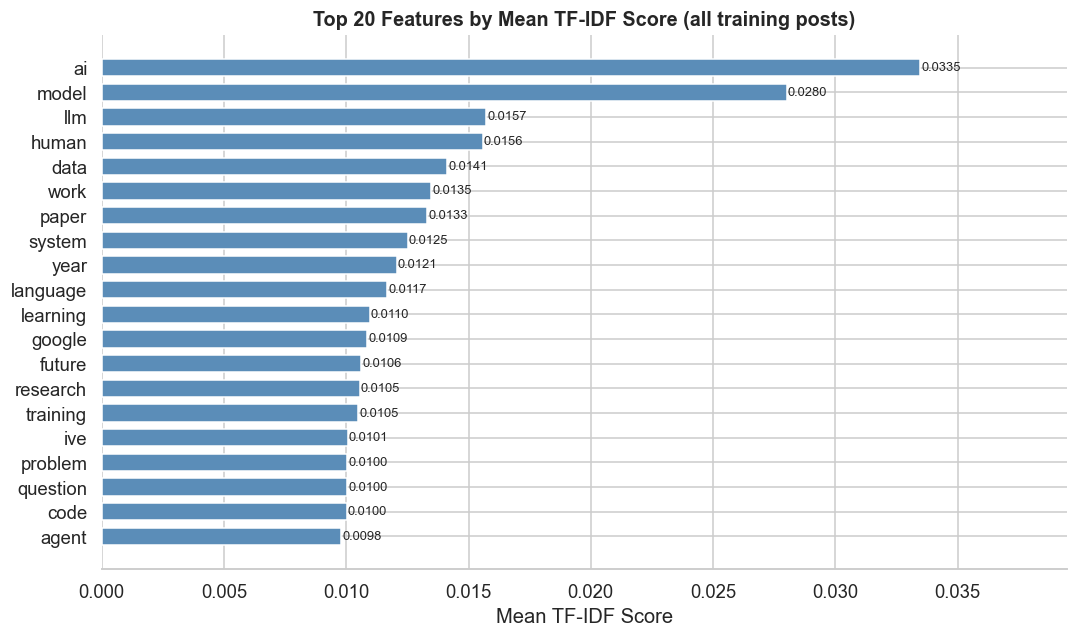

Unigrams in top 20: ['ai', 'model', 'llm', 'human', 'data', 'work', 'paper', 'system', 'year', 'language', 'learning', 'google', 'future', 'research', 'training', 'ive', 'problem', 'question', 'code', 'agent']
Bigrams  in top 20: []


In [39]:
# Mean TF-IDF score per feature across all training docs
mean_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top20_idx  = mean_tfidf.argsort()[-20:][::-1]
top20_words  = [feature_names[i] for i in top20_idx]
top20_scores = [mean_tfidf[i] for i in top20_idx]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top20_words[::-1], top20_scores[::-1], color='#5B8DB8', edgecolor='white', height=0.7)

for bar, val in zip(bars, top20_scores[::-1]):
    ax.text(bar.get_width() + 0.00005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8.5)

ax.set_title('Top 20 Features by Mean TF-IDF Score (all training posts)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
ax.set_xlim(0, max(top20_scores) * 1.18)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

# Separate unigrams from bigrams in the top 20
unigrams = [w for w in top20_words if ' ' not in w]
bigrams  = [w for w in top20_words if ' ' in w]
print(f'Unigrams in top 20: {unigrams}')
print(f'Bigrams  in top 20: {bigrams}')

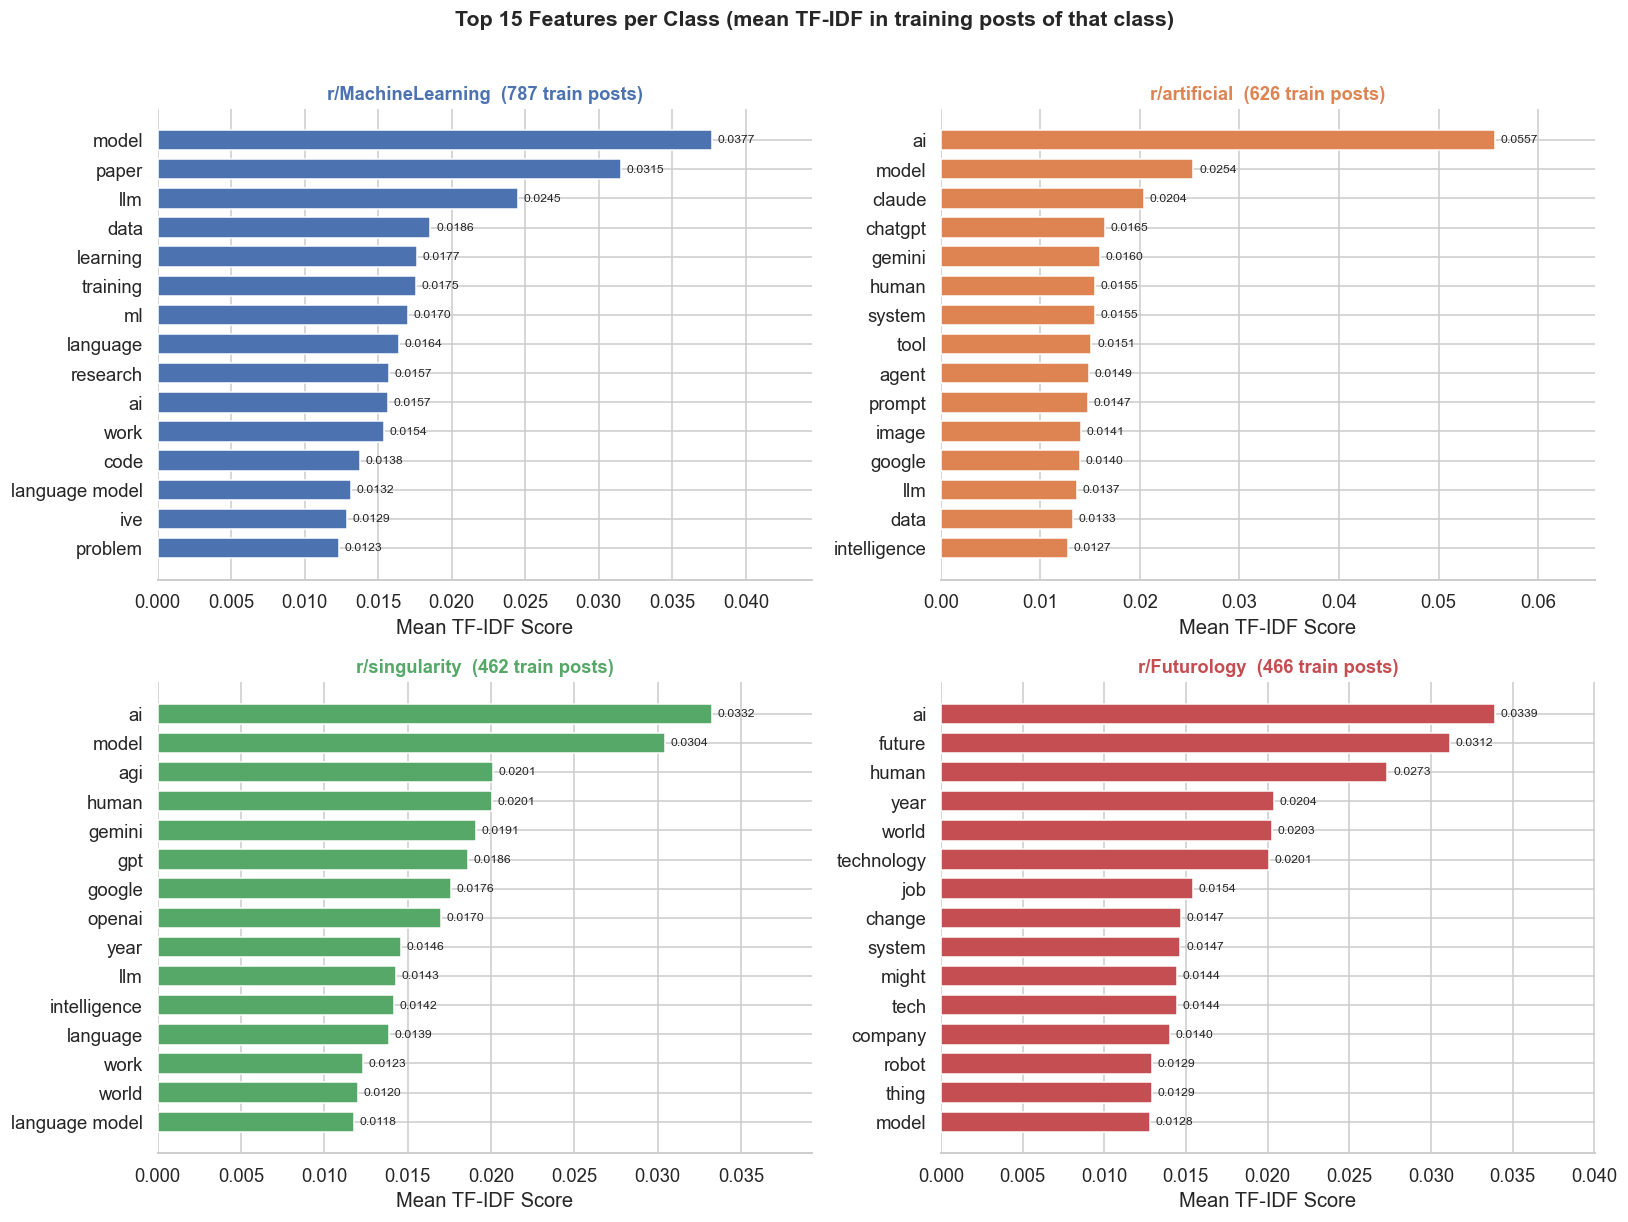

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

y_train_arr = np.array(y_train)

per_class_top = {}

for i, sub in enumerate(SUB_ORDER):
    # Rows in training set belonging to this subreddit
    mask        = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    
    # Mean TF-IDF per feature for this class
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    top15_idx    = mean_scores.argsort()[-15:]  # ascending, so last 15 = highest
    top15_words  = [feature_names[j] for j in top15_idx]
    top15_scores = [mean_scores[j]   for j in top15_idx]
    
    per_class_top[sub] = list(zip(top15_words, top15_scores))
    
    ax = axes[i]
    bars = ax.barh(top15_words, top15_scores, color=PALETTE[sub], edgecolor='white', height=0.7)
    
    for bar, val in zip(bars, top15_scores):
        ax.text(bar.get_width() + max(top15_scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    
    n_class = mask.sum()
    ax.set_title(f'r/{sub}  ({n_class} train posts)', fontsize=12, fontweight='bold', color=PALETTE[sub])
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_xlim(0, max(top15_scores) * 1.18)
    sns.despine(ax=ax, left=True)

fig.suptitle('Top 15 Features per Class (mean TF-IDF in training posts of that class)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 8 — Bigram Analysis

Since `ngram_range=(1,2)` was set, the vocabulary includes two-word phrases. Bigrams are often more discriminative than single words for AI text — "language model" as a phrase carries different meaning than "language" and "model" separately. Here we isolate only bigram features and show the top ones per class.

Total features     : 15,000
Unigram features   : 8,660
Bigram features    : 6,340



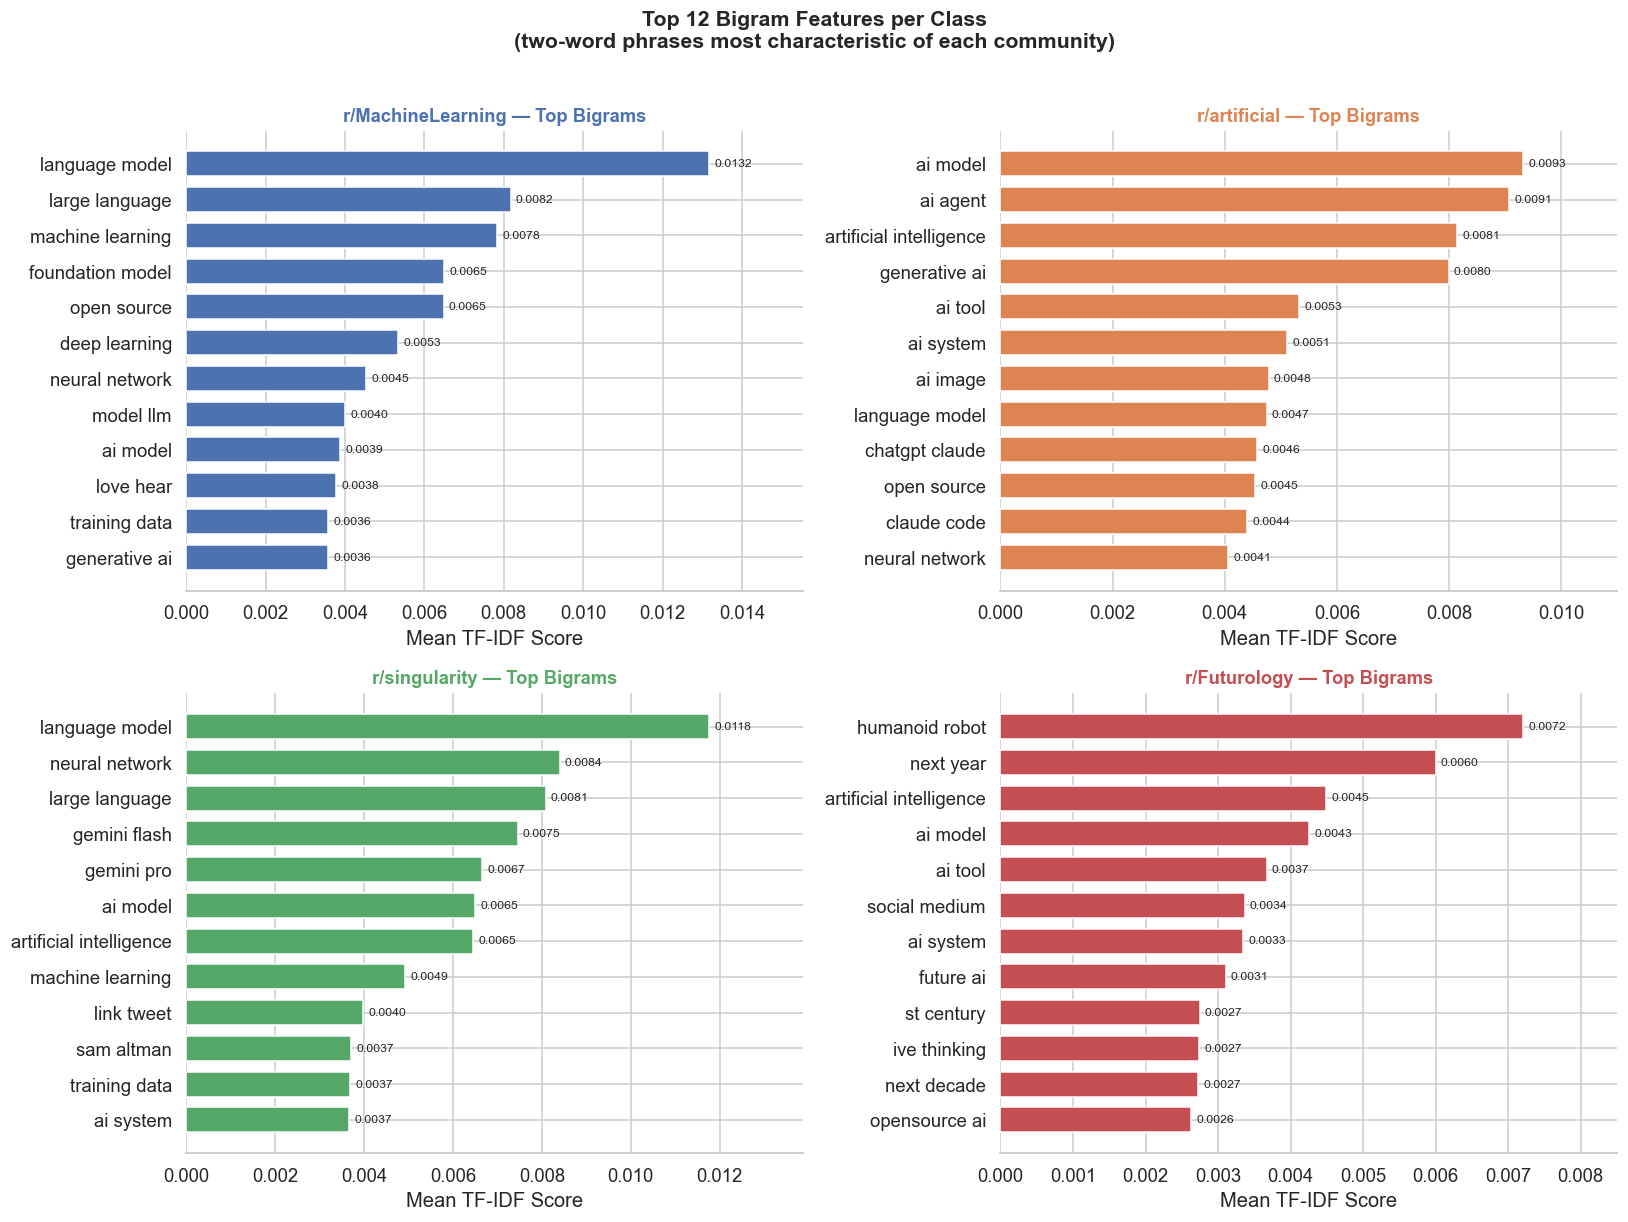

In [41]:
# Bigram indices — any feature name that contains a space
bigram_idx = np.array([i for i, f in enumerate(feature_names) if ' ' in f])
print(f'Total features     : {len(feature_names):,}')
print(f'Unigram features   : {len(feature_names) - len(bigram_idx):,}')
print(f'Bigram features    : {len(bigram_idx):,}')
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

y_train_arr = np.array(y_train)

for i, sub in enumerate(SUB_ORDER):
    mask         = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    
    # Restrict to bigrams only
    bigram_scores = mean_scores[bigram_idx]
    top12_local   = bigram_scores.argsort()[-12:]
    top12_words   = [feature_names[bigram_idx[j]] for j in top12_local]
    top12_scores  = [bigram_scores[j]             for j in top12_local]
    
    ax = axes[i]
    bars = ax.barh(top12_words, top12_scores, color=PALETTE[sub], edgecolor='white', height=0.7)
    
    for bar, val in zip(bars, top12_scores):
        ax.text(bar.get_width() + max(top12_scores) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    
    ax.set_title(f'r/{sub} — Top Bigrams', fontsize=12, fontweight='bold', color=PALETTE[sub])
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_xlim(0, max(top12_scores) * 1.18)
    sns.despine(ax=ax, left=True)

fig.suptitle('Top 12 Bigram Features per Class\n(two-word phrases most characteristic of each community)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 9 — Feature Overlap Between Classes

How many of the top 100 features per class are shared across classes?

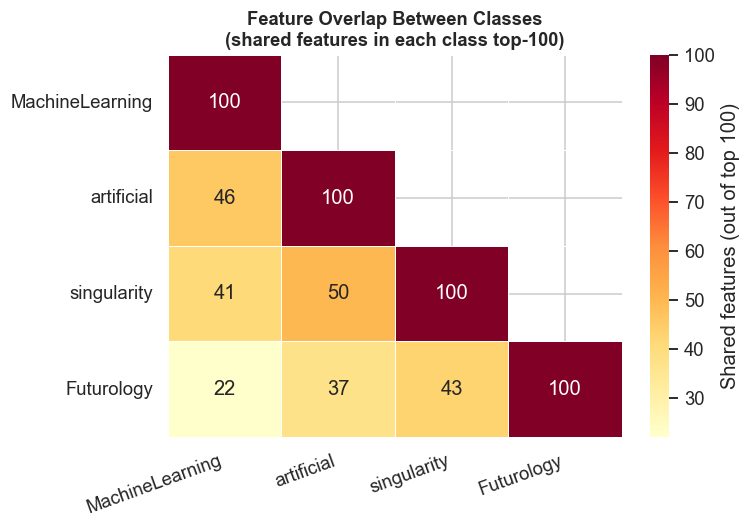


Key insight:
  MachineLearning      vs artificial          :  46 / 100 features shared  (46%)
  MachineLearning      vs singularity         :  41 / 100 features shared  (41%)
  MachineLearning      vs Futurology          :  22 / 100 features shared  (22%)
  artificial           vs singularity         :  50 / 100 features shared  (50%)
  artificial           vs Futurology          :  37 / 100 features shared  (37%)
  singularity          vs Futurology          :  43 / 100 features shared  (43%)


In [42]:
N = 100  # top-N features per class to compare

y_train_arr   = np.array(y_train)
top_features  = {}

for sub in SUB_ORDER:
    mask         = y_train_arr == sub
    class_matrix = X_train_tfidf[mask]
    mean_scores  = np.asarray(class_matrix.mean(axis=0)).flatten()
    top_idx      = mean_scores.argsort()[-N:]
    top_features[sub] = set(feature_names[top_idx])

# Build pairwise overlap matrix
overlap = pd.DataFrame(index=SUB_ORDER, columns=SUB_ORDER, dtype=int)
for s1 in SUB_ORDER:
    for s2 in SUB_ORDER:
        overlap.loc[s1, s2] = len(top_features[s1] & top_features[s2])

fig, ax = plt.subplots(figsize=(7, 5))
mask_upper = np.triu(np.ones_like(overlap, dtype=bool), k=1)
sns.heatmap(
    overlap.astype(int), annot=True, fmt='d',
    cmap='YlOrRd', linewidths=0.5,
    mask=mask_upper, ax=ax,
    cbar_kws={'label': f'Shared features (out of top {N})'}
)
ax.set_title(f'Feature Overlap Between Classes\n(shared features in each class top-{N})',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(SUB_ORDER, rotation=20, ha='right')
ax.set_yticklabels(SUB_ORDER, rotation=0)
plt.tight_layout()
plt.show()

print('\nKey insight:')
pairs = [(s1, s2) for i, s1 in enumerate(SUB_ORDER) for s2 in SUB_ORDER[i+1:]]
for s1, s2 in pairs:
    shared = len(top_features[s1] & top_features[s2])
    print(f'  {s1:20s} vs {s2:20s}: {shared:3d} / {N} features shared  ({shared}%)')

In [43]:
save_dir = Path('data/tfidf_artifacts')
save_dir.mkdir(parents=True, exist_ok=True)

# Save fitted vectorizer
joblib.dump(vectorizer, save_dir / 'tfidf_vectorizer.joblib')

# Save sparse matrices
scipy.sparse.save_npz(save_dir / 'X_train.npz', X_train_tfidf)
scipy.sparse.save_npz(save_dir / 'X_test.npz',  X_test_tfidf)

# Save labels
np.save(save_dir / 'y_train.npy', np.array(y_train))
np.save(save_dir / 'y_test.npy',  np.array(y_test))

print('Saved to data/tfidf_artifacts/')
for f in sorted(save_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:35s}  {size_kb:7.1f} KB')

print()
print('Notebook 04 can now load these directly — no need to rerun preprocessing.')

Saved to data/tfidf_artifacts/
  X_test.npz                             527.7 KB
  X_train.npz                           2112.0 KB
  tfidf_vectorizer.joblib                584.4 KB
  y_test.npy                               1.5 KB
  y_train.npy                              4.9 KB

Notebook 04 can now load these directly — no need to rerun preprocessing.


## Summary

| Step | Result |
|---|---|
| Posts loaded | 2,927 across 4 subreddits |
| After preprocessing | Same 2,927 — no posts dropped |
| Train / test split | 2,341 train  /  586 test  (80/20 stratified) |
| TF-IDF vocabulary | 15,000 features (unigrams + bigrams, after min_df/max_df filtering) |
| Matrix sparsity | 99.23% sparse — handled efficiently by scipy sparse storage |
| Matrix size | 3.2 MB sparse vs 281 MB if stored as a full dense matrix |
| Artifacts saved | vectorizer, X_train, X_test, y_train, y_test |